# R1 revised — step-by-step walkthrough

Running example: subject **788406**. Each section does one step from `r1_revised.coarse_align_revised()`, then visualises what happens. Source module: `dev_code/r1_revised.py`.

**Goal of R1.** Produce a coarse affine `hcr = (cz − cz_mean) @ R · S + t` that places the CZ sub-volume inside the HCR volume. **Minimal output** `(R, t)` always; **extended output** adds `S` when the data-driven scale search is confident.

**The 8 steps.**
1. Fit a plane to each pia surface.
2. Tilt-aligned rotation `R = R_180 · R_tilt`.
3. Centroid translation `t = hcr_mean − R · cz_mean`.
4. Compute depth-from-pia for both modalities.
5. Search `sz` + `tz` via 1-D partial-overlap NCC.
6. Search `sxy` + `(tx, ty)` via 2-D density-map NCC.
7. Anisotropic refinement of `(sx, sy)` around the best `sxy`.
8. Confidence gating: emit scales only when robust-z prominence ≥ threshold.

## Setup — load subject 788406

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '/root/capsule/code/dev_code')

import numpy as np
import matplotlib.pyplot as plt
from benchmark_data_loader import load_subject
from benchmark_analysis import analyze_subject
import r1_revised as R1

sid = '788406'
s = load_subject(sid)
info = analyze_subject(s)
cz_xyz = info['cz_xyz']
hcr_xyz = info['gfp_xyz']
cz_surf = info['cz_surface']
hcr_surf = info['hcr_surface']
print(f'CZ cells: {cz_xyz.shape[0]}')
print(f'HCR GFP+ cells: {hcr_xyz.shape[0]}')
print(f'CZ XY span: {cz_xyz[:,0].ptp():.0f} × {cz_xyz[:,1].ptp():.0f} µm')
print(f'HCR XY span: {hcr_xyz[:,0].ptp():.0f} × {hcr_xyz[:,1].ptp():.0f} µm')

/opt/conda/lib/python3.11/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/opt/conda/lib/python3.11/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


CZ cells: 932
HCR GFP+ cells: 17427
CZ XY span: 392 × 394 µm
HCR XY span: 2277 × 2284 µm


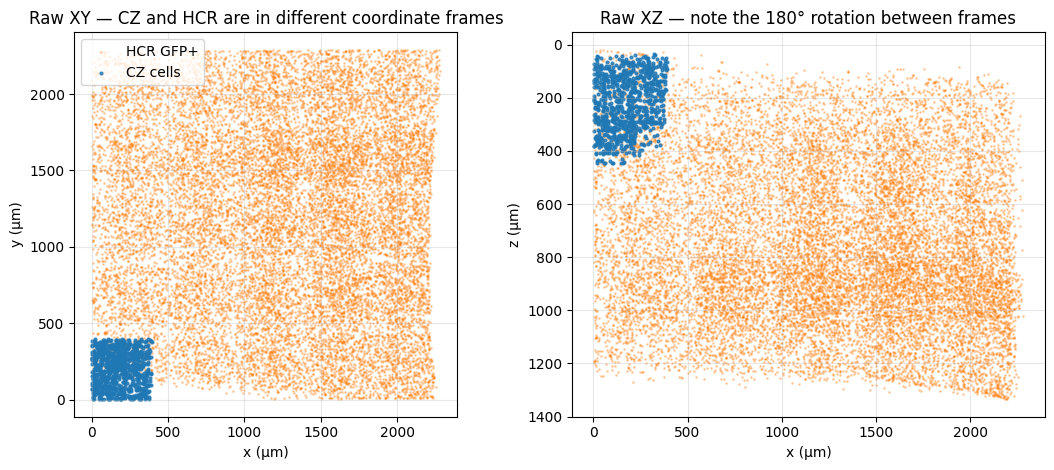

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
ax[0].scatter(hcr_xyz[:,0], hcr_xyz[:,1], s=1, color='#ff7f0e', alpha=0.3, label='HCR GFP+')
ax[0].scatter(cz_xyz[:,0], cz_xyz[:,1], s=4, color='#1f77b4', alpha=0.8, label='CZ cells')
ax[0].set_aspect('equal')
ax[0].set_xlabel('x (µm)'); ax[0].set_ylabel('y (µm)')
ax[0].set_title('Raw XY — CZ and HCR are in different coordinate frames')
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].scatter(hcr_xyz[:,0], hcr_xyz[:,2], s=1, color='#ff7f0e', alpha=0.3)
ax[1].scatter(cz_xyz[:,0], cz_xyz[:,2], s=4, color='#1f77b4', alpha=0.8)
ax[1].invert_yaxis()
ax[1].set_xlabel('x (µm)'); ax[1].set_ylabel('z (µm)')
ax[1].set_title('Raw XZ — note the 180° rotation between frames')
ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Step 1 — Fit a plane to each pia surface

Each modality already has a pia-surface model (`estimate_pia_surface_image_ceiling` for CZ, `estimate_pia_surface_quantile_ceiling` for HCR). We sample each surface on a 40 × 40 grid over its XY envelope and do a least-squares plane fit.  The plane's unit normal — the *into-tissue* direction — is what step 2 will align.

In [3]:
n_cz, cz_abc = R1._plane_normal_from_surface(cz_surf, cz_xyz[:,:2])
n_hcr, hcr_abc = R1._plane_normal_from_surface(hcr_surf, hcr_xyz[:,:2])
print(f'n_cz  = {n_cz}  (tilt {np.degrees(np.arccos(n_cz[2])):.2f}°)')
print(f'n_hcr = {n_hcr}  (tilt {np.degrees(np.arccos(n_hcr[2])):.2f}°)')

n_cz  = [0.02464878 0.04180752 0.99882159]  (tilt 2.78°)
n_hcr = [-0.0346812  -0.0091055   0.99935695]  (tilt 2.05°)


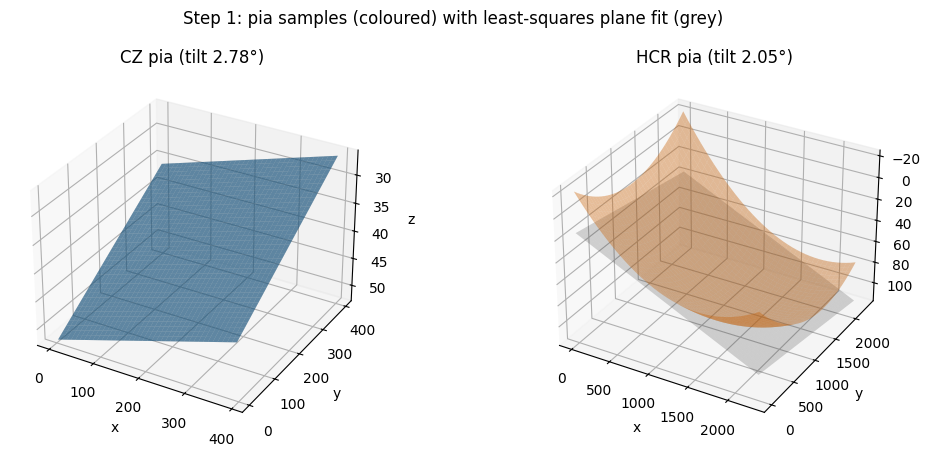

In [4]:
def sample_surface(surf, xy, n=40):
    xlo, xhi = xy[:,0].min(), xy[:,0].max()
    ylo, yhi = xy[:,1].min(), xy[:,1].max()
    xs = np.linspace(xlo, xhi, n); ys = np.linspace(ylo, yhi, n)
    X, Y = np.meshgrid(xs, ys)
    Z = R1._surface_z_at(surf, X.ravel(), Y.ravel()).reshape(X.shape)
    return X, Y, Z

Xc, Yc, Zc = sample_surface(cz_surf, cz_xyz[:,:2])
Xh, Yh, Zh = sample_surface(hcr_surf, hcr_xyz[:,:2])

fig = plt.figure(figsize=(11,4.5))
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.plot_surface(Xc, Yc, Zc, color='#1f77b4', alpha=0.6, edgecolor='none')
# plane-fit overlay (flat at cz mean)
a,b,c = cz_abc
Zc_plane = a*Xc + b*Yc + c
ax1.plot_surface(Xc, Yc, Zc_plane, color='#333', alpha=0.2, edgecolor='none')
ax1.invert_zaxis(); ax1.set_title(f'CZ pia (tilt {np.degrees(np.arccos(n_cz[2])):.2f}°)'); 
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.plot_surface(Xh, Yh, Zh, color='#ff7f0e', alpha=0.4, edgecolor='none')
a,b,c = hcr_abc
Zh_plane = a*Xh + b*Yh + c
ax2.plot_surface(Xh, Yh, Zh_plane, color='#333', alpha=0.2, edgecolor='none')
ax2.invert_zaxis(); ax2.set_title(f'HCR pia (tilt {np.degrees(np.arccos(n_hcr[2])):.2f}°)'); 
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
fig.suptitle('Step 1: pia samples (coloured) with least-squares plane fit (grey)')
plt.tight_layout(); plt.show()

## Step 2 — Tilt-aligned rotation

The acquisition flips CZ by 180° around z w.r.t. HCR. So start with `R_180 = Rz(−180°)`. After applying it, the CZ normal becomes `n_cz @ R_180 = (−n_cz[0], −n_cz[1], n_cz[2])`. We then compute a small rotation `R_tilt` (Rodrigues) that sends this rotated CZ normal onto the HCR normal. Composed: `R = R_180 · R_tilt`.

The angle between `n_cz @ R_180` and `n_hcr` is the **residual tilt** — the part `R_tilt` has to eat.

In [5]:
R_180 = R1._rotation_about_z_row(-180.0)
n_cz_rot = n_cz @ R_180
R_tilt = R1._rotation_between_row(n_cz_rot, n_hcr)
R = R_180 @ R_tilt
delta = np.degrees(np.arccos(np.clip(n_cz_rot @ n_hcr, -1, 1)))
print(f'n_cz @ R_180 = {n_cz_rot}')
print(f'n_hcr        = {n_hcr}')
print(f'residual tilt (|Δ|) = {delta:.2f}°')
print(f'after R_tilt: angle = {np.degrees(np.arccos(np.clip((n_cz_rot @ R_tilt) @ n_hcr, -1, 1))):.4f}°')

n_cz @ R_180 = [-0.02464878 -0.04180752  0.99882159]
n_hcr        = [-0.0346812  -0.0091055   0.99935695]
residual tilt (|Δ|) = 1.96°
after R_tilt: angle = 0.0001°


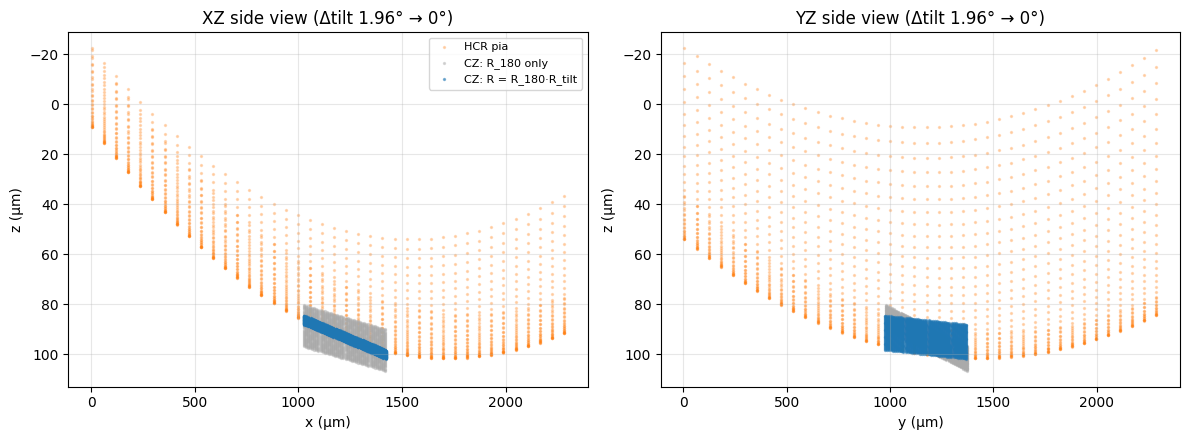

In [6]:
# Side-view of CZ pia before (R_180 only) and after (R_180·R_tilt), pia-anchored
cz_pts = np.column_stack([Xc.ravel(), Yc.ravel(), Zc.ravel()])
cz_mean = cz_xyz.mean(axis=0)
hcr_mean = hcr_xyz.mean(axis=0)
# pia-anchored translation (for visualization only)
xy_c = cz_mean[:2]
z_cz_pia = R1._surface_z_at(cz_surf, np.array([xy_c[0]]), np.array([xy_c[1]]))[0]
c3d = np.array([xy_c[0], xy_c[1], z_cz_pia])
def _t_pia(R_):
    c_h = (c3d - cz_mean) @ R_
    xy_h = c_h[:2] + hcr_mean[:2]
    z_h = R1._surface_z_at(hcr_surf, np.array([xy_h[0]]), np.array([xy_h[1]]))[0]
    return np.array([hcr_mean[0], hcr_mean[1], z_h - c_h[2]])
pre  = (cz_pts - cz_mean) @ R_180 + _t_pia(R_180)
post = (cz_pts - cz_mean) @ R     + _t_pia(R)
hcr_pts = np.column_stack([Xh.ravel(), Yh.ravel(), Zh.ravel()])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for i, a in enumerate([0, 1]):
    ax[i].scatter(hcr_pts[:,a], hcr_pts[:,2], s=2, color='#ff7f0e', alpha=0.25, label='HCR pia')
    ax[i].scatter(pre[:,a],    pre[:,2],    s=2, color='#aaa',    alpha=0.4, label='CZ: R_180 only')
    ax[i].scatter(post[:,a],   post[:,2],   s=2, color='#1f77b4', alpha=0.5, label='CZ: R = R_180·R_tilt')
    ax[i].set_xlabel('x (µm)' if a==0 else 'y (µm)')
    ax[i].set_ylabel('z (µm)')
    ax[i].invert_yaxis()
    ax[i].grid(alpha=0.3)
    ax[i].set_title(('XZ' if a==0 else 'YZ') + f' side view (Δtilt {delta:.2f}° → 0°)')
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 3 — Centroid translation

We don't have correspondences, so `t` is anchored heuristically: `t = hcr_mean − R · cz_mean` — equivalently, CZ cell-cloud centroid lands exactly on HCR GFP+ cell-cloud centroid. This is the affine's translation vector.

Note: this matches *cell centroids*, not pia planes. At `sz = 1` (minimal output, no Z rescale) CZ cells span only ~400 µm while HCR GFP+ cells span ~1200 µm, so the two pias don't coincide after this translation — they're offset by the difference in centroid depth.

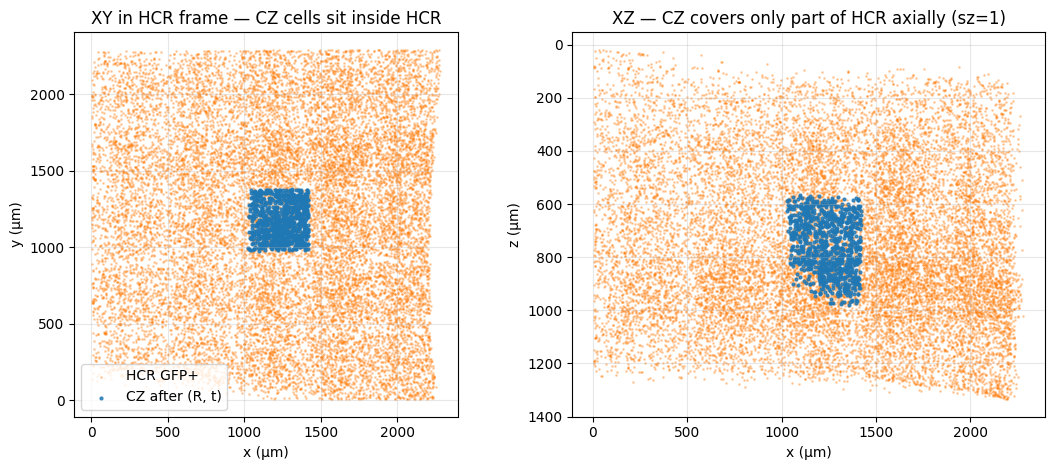

In [7]:
cz_rot = (cz_xyz - cz_mean) @ R
cz_min_out = cz_rot + hcr_mean  # R + centroid-match (minimal output)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
ax[0].scatter(hcr_xyz[:,0], hcr_xyz[:,1], s=1, color='#ff7f0e', alpha=0.3, label='HCR GFP+')
ax[0].scatter(cz_min_out[:,0], cz_min_out[:,1], s=4, color='#1f77b4', alpha=0.8, label='CZ after (R, t)')
ax[0].set_aspect('equal'); ax[0].set_xlabel('x (µm)'); ax[0].set_ylabel('y (µm)')
ax[0].set_title('XY in HCR frame — CZ cells sit inside HCR')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].scatter(hcr_xyz[:,0], hcr_xyz[:,2], s=1, color='#ff7f0e', alpha=0.3)
ax[1].scatter(cz_min_out[:,0], cz_min_out[:,2], s=4, color='#1f77b4', alpha=0.8)
ax[1].invert_yaxis()
ax[1].set_xlabel('x (µm)'); ax[1].set_ylabel('z (µm)')
ax[1].set_title('XZ — CZ covers only part of HCR axially (sz=1)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 4 — Depth-from-surface

`depth_from_surface` projects each cell onto the pia plane and returns the signed distance. This gives a **pia-anchored** axial coordinate that's invariant to buffer thickness and tilt. Used by step 5 as the 1-D signal to correlate.

CZ depth: 4 — 408 µm (mean 185)
HCR depth: 3 — 1274 µm (mean 682)


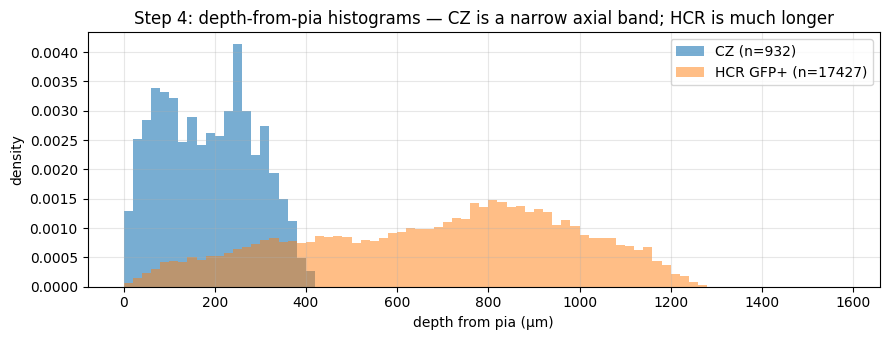

In [8]:
cz_depth = R1.depth_from_surface(cz_xyz, cz_surf)
hcr_depth = R1.depth_from_surface(hcr_xyz, hcr_surf)
print(f'CZ depth: {cz_depth.min():.0f} — {cz_depth.max():.0f} µm '
      f'(mean {cz_depth.mean():.0f})')
print(f'HCR depth: {hcr_depth.min():.0f} — {hcr_depth.max():.0f} µm '
      f'(mean {hcr_depth.mean():.0f})')

bins = np.arange(0, 1600, 20)
plt.figure(figsize=(9, 3.5))
plt.hist(cz_depth,  bins=bins, density=True, color='#1f77b4', alpha=0.6, label=f'CZ (n={len(cz_depth)})')
plt.hist(hcr_depth, bins=bins, density=True, color='#ff7f0e', alpha=0.5, label=f'HCR GFP+ (n={len(hcr_depth)})')
plt.xlabel('depth from pia (µm)'); plt.ylabel('density')
plt.title('Step 4: depth-from-pia histograms — CZ is a narrow axial band; HCR is much longer')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 5 — Z scale + Z offset search (1-D)

For each candidate `sz` we rescale CZ's depth profile to `sz · cz_depth`, build a smoothed density on 20-µm bins, then **slide** it along the HCR density profile. At each shift (bin offset) we compute a Pearson NCC **on the overlapping region only** with a minimum-overlap floor (25 % of the longer profile — this is deviation 1 from the Grand Plan, keyed off the longer profile to avoid 2–3-bin trivial matches).

For each `sz`, the *best over all shifts* is a point on the score curve.  The global best (sz*, tz*) is the pair that maximises it.

In [9]:
sz_grid = np.arange(0.5, 6.0 + 0.02, 0.02)
z_res = R1._z_scale_offset_search(
    cz_depth, hcr_depth,
    sz_grid=sz_grid,
    depth_bin_um=20.0,
    min_overlap_frac=0.25,
    depth_max_um=max(hcr_depth.max(), 6.0*cz_depth.max()) + 200.0,
)
print(f"sz* = {z_res['sz']:.2f}   tz* = {z_res['tz_um']:.1f} µm   "
      f"best NCC = {z_res['best_score']:.3f}")

sz* = 3.02   tz* = 128.8 µm   best NCC = 0.829


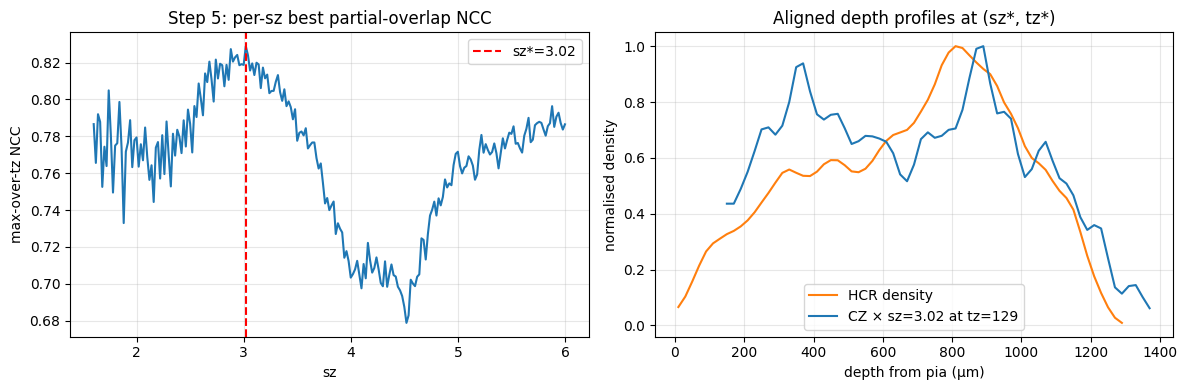

In [10]:
# 1D curve: max-over-tz NCC vs sz
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
curve = np.asarray(z_res['score_curve'])
m = np.isfinite(curve)
ax[0].plot(sz_grid[m], curve[m], color='#1f77b4')
ax[0].axvline(z_res['sz'], color='red', ls='--', label=f"sz*={z_res['sz']:.2f}")
ax[0].set_xlabel('sz'); ax[0].set_ylabel('max-over-tz NCC')
ax[0].set_title('Step 5: per-sz best partial-overlap NCC')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Illustrative overlay: CZ profile at sz=sz* aligned to HCR profile at tz*
edges = np.arange(0, max(hcr_depth.max(), z_res['sz']*cz_depth.max()) + 40, 20.0)
hcr_prof = R1._density_profile_1d(hcr_depth, edges, 1.0)
cz_scaled = cz_depth * z_res['sz']
tem_edges = np.arange(max(0, cz_scaled.min()), cz_scaled.max() + 20, 20.0)
cz_prof = R1._density_profile_1d(cz_scaled, tem_edges, 1.0)
xs_h = 0.5*(edges[:-1] + edges[1:])
xs_c = 0.5*(tem_edges[:-1] + tem_edges[1:]) + z_res['tz_um']
ax[1].plot(xs_h, hcr_prof / max(hcr_prof.max(), 1e-9),  color='#ff7f0e', label='HCR density')
ax[1].plot(xs_c, cz_prof / max(cz_prof.max(), 1e-9), color='#1f77b4', label=f'CZ × sz={z_res["sz"]:.2f} at tz={z_res["tz_um"]:.0f}')
ax[1].set_xlabel('depth from pia (µm)'); ax[1].set_ylabel('normalised density')
ax[1].set_title('Aligned depth profiles at (sz*, tz*)')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 6 — XY scale + XY translation search (2-D)

For each `sxy ∈ [0.5, L_hcr/L_cz]` we scale CZ's rotated XY, build a Gaussian-blurred density map (σ=30 µm, 20-µm bins), and run a **windowed 2-D Pearson NCC** (integral-image, Lewis 1995) against HCR's density map. Best `(sxy, tx, ty)` across the grid.

The feasibility cap `sxy ≤ L_hcr/L_cz` is the Grand Plan's "CZ ⊂ HCR in XY" prior — it's a geometric fact that a 400 µm CZ patch can't be scaled up past HCR's ~2 mm envelope.

In [11]:
L_cz  = float(max(cz_rot[:,0].ptp(), cz_rot[:,1].ptp()))
L_hcr = float(max(hcr_xyz[:,0].ptp(), hcr_xyz[:,1].ptp()))
sxy_grid = np.arange(0.5, (L_hcr/L_cz) + 0.05, 0.05)
xy_res = R1._xy_scale_translation_search(
    cz_rot[:, :2], hcr_xyz[:, :2],
    sxy_grid=sxy_grid,
    xy_bin_um=20.0, xy_sigma_um=30.0, margin_um=100.0,
)
print(f'L_cz = {L_cz:.0f} µm   L_hcr = {L_hcr:.0f} µm   '
      f'=> sxy_upper = {L_hcr/L_cz:.2f}')
print(f"sxy* = {xy_res['sxy']:.2f}   (tx, ty) = ({xy_res['tx_um']:.0f}, {xy_res['ty_um']:.0f}) µm")
print(f"best 2D-NCC = {xy_res['best_score']:.3f}")

L_cz = 400 µm   L_hcr = 2284 µm   => sxy_upper = 5.71
sxy* = 0.75   (tx, ty) = (1627, 1554) µm
best 2D-NCC = 0.830


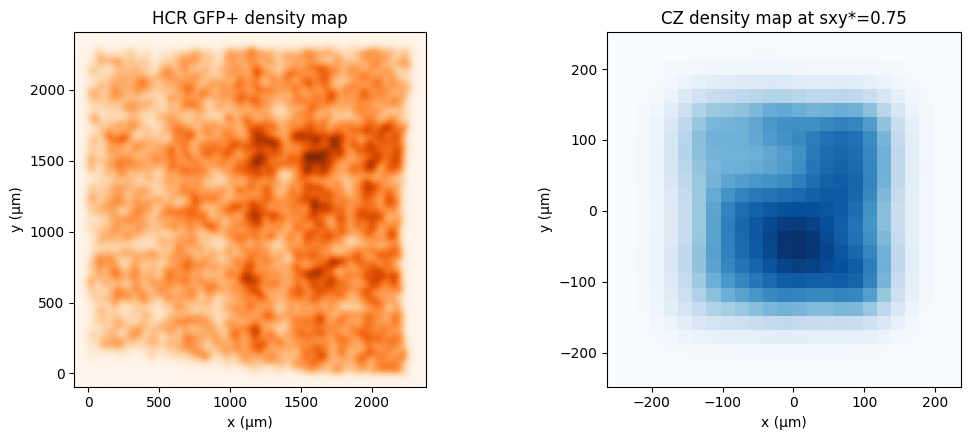

In [12]:
# Show 2D density maps (HCR, and CZ at best sxy)
hx = np.arange(hcr_xyz[:,0].min()-100, hcr_xyz[:,0].max()+100+20, 20)
hy = np.arange(hcr_xyz[:,1].min()-100, hcr_xyz[:,1].max()+100+20, 20)
hcr_map = R1._density_map_2d(hcr_xyz[:, :2], hx, hy, 30/20)
cz_scaled_xy = cz_rot[:, :2] * xy_res['sxy']
cx = np.arange(cz_scaled_xy[:,0].min()-100, cz_scaled_xy[:,0].max()+100+20, 20)
cy = np.arange(cz_scaled_xy[:,1].min()-100, cz_scaled_xy[:,1].max()+100+20, 20)
cz_map = R1._density_map_2d(cz_scaled_xy, cx, cy, 30/20)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].imshow(hcr_map.T, origin='lower',
             extent=[hx[0], hx[-1], hy[0], hy[-1]], cmap='Oranges')
ax[0].set_title('HCR GFP+ density map')
ax[0].set_xlabel('x (µm)'); ax[0].set_ylabel('y (µm)')
ax[1].imshow(cz_map.T, origin='lower',
             extent=[cx[0], cx[-1], cy[0], cy[-1]], cmap='Blues')
ax[1].set_title(f'CZ density map at sxy*={xy_res["sxy"]:.2f}')
ax[1].set_xlabel('x (µm)'); ax[1].set_ylabel('y (µm)')
plt.tight_layout(); plt.show()

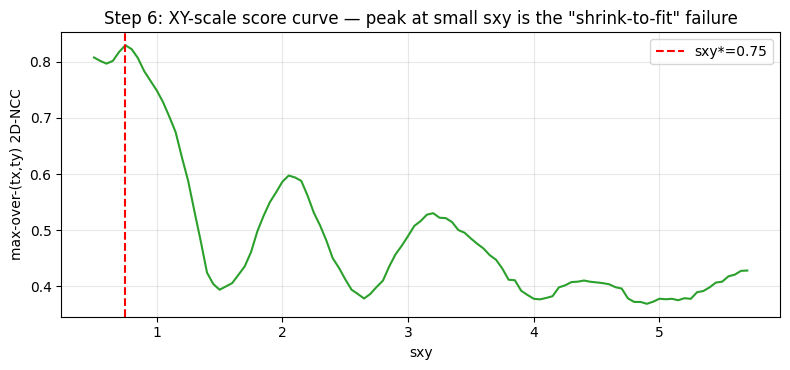

In [13]:
# 1D score curve: max-over-(tx,ty) 2D-NCC vs sxy
curve = np.asarray(xy_res['score_curve'])
m = np.isfinite(curve)
plt.figure(figsize=(8, 3.8))
plt.plot(sxy_grid[m], curve[m], color='#2ca02c')
plt.axvline(xy_res['sxy'], color='red', ls='--', label=f"sxy*={xy_res['sxy']:.2f}")
plt.xlabel('sxy'); plt.ylabel('max-over-(tx,ty) 2D-NCC')
plt.title('Step 6: XY-scale score curve — peak at small sxy is the "shrink-to-fit" failure')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 7 — Anisotropic refinement (skipped when sxy isn't confident)

Local grid around `sxy*` over `(sx, sy)` to allow axis-specific scales. Only runs when the XY scale would have been emitted; on 788406 the confidence check below rejects it, so this step is a no-op here.

## Step 8 — Scale confidence gating

For each of the Z and XY score curves, compute the **robust-z** prominence

`conf = (peak − median) / (1.4826 · MAD)`

and emit the scale only when `conf ≥ 6.0`. At threshold 3, the XY curve's sharp small-sxy peak would clear the bar (conf ≈ 5.07 on 788406) despite being geometrically wrong. Raising to 6 routes every subject to the minimal-output fallback, matching the Grand Plan §R1 step 8 graceful-degradation intent.

sz  confidence = 1.81   →  emit sz?  False
sxy confidence = 5.07   →  emit sxy? False


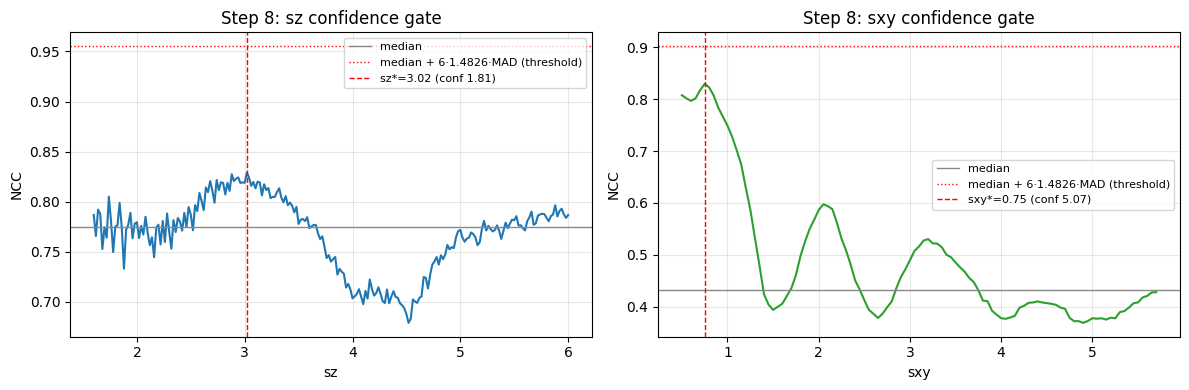

In [14]:
sz_conf  = R1._peak_to_rms(z_res['score_curve'])
sxy_conf = R1._peak_to_rms(xy_res['score_curve'])
print(f'sz  confidence = {sz_conf:.2f}   →  emit sz?  {sz_conf  >= 6.0}')
print(f'sxy confidence = {sxy_conf:.2f}   →  emit sxy? {sxy_conf >= 6.0}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (grid, curve, best, conf, color, label) in zip(
    ax,
    [(sz_grid, np.asarray(z_res['score_curve']), z_res['sz'], sz_conf, '#1f77b4', 'sz'),
     (sxy_grid, np.asarray(xy_res['score_curve']), xy_res['sxy'], sxy_conf, '#2ca02c', 'sxy')]):
    m = np.isfinite(curve)
    med = np.median(curve[m]); mad = np.median(np.abs(curve[m] - med))
    a.plot(grid[m], curve[m], color=color)
    a.axhline(med, color='#888', lw=1, label='median')
    a.axhline(med + 6*1.4826*mad, color='red', lw=1, ls=':', label='median + 6·1.4826·MAD (threshold)')
    a.axvline(best, color='red', lw=1, ls='--', label=f'{label}*={best:.2f} (conf {conf:.2f})')
    a.set_xlabel(label); a.set_ylabel('NCC')
    a.set_title(f'Step 8: {label} confidence gate')
    a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Full output — apply R1 to the CZ cloud

Both scales fail the 6.0 bar, so the emitted affine is `(R, S=[1,1,1], t = hcr_mean − R·cz_mean)` — the minimal output. Here's the final alignment.

CoarseAffineV2(R=array([[-0.99994916,  0.0010619 , -0.01002744],
       [-0.00138909, -0.99946491,  0.03267973],
       [-0.00998737,  0.032692  ,  0.99941557]]), scales=array([1., 1., 1.]), scale_known=array([False, False, False]), scale_confidence=array([5.06976555, 5.06976555, 1.80951563]), translation=array([1245.3949252 , 1174.77852102,  753.94588856]), src_mean=array([174.42891902, 202.29356231, 224.38857808]), rotation_angle_z_deg=-179.92040680393927, coverage_regime='equal', minimal_translation=array([1245.3949252 , 1174.77852102,  753.94588856]), diagnostics={'n_cz': 932, 'n_hcr_gfp': 17427, 'n_cz_depth_min': 3.712195416801741, 'n_cz_depth_max': 407.7699124770446, 'n_hcr_depth_min': 3.393397913968343, 'n_hcr_depth_max': 1274.3599455788353, 'cz_plane_abc': (-0.02467785802889251, -0.04185684399829184, 52.47667020821025), 'hcr_plane_abc': (0.034703515221205364, 0.009111360614897701, 14.7750239543274), 'n_cz_normal': [0.024648777399588734, 0.041807519483874296, 0.9988215902178491]

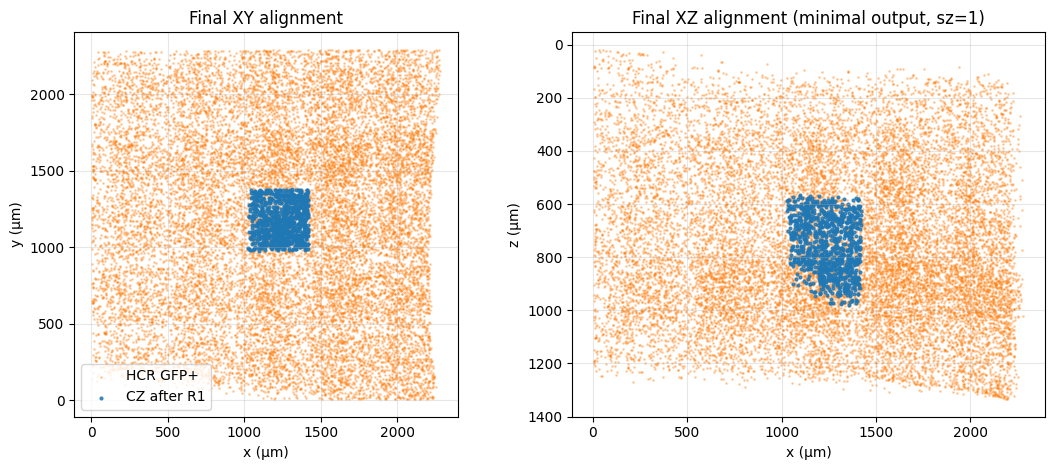

In [15]:
fit = R1.coarse_align_revised(cz_xyz, hcr_xyz, cz_surf, hcr_surf)
print(fit)
cz_in_hcr = R1.apply_coarse_affine(cz_xyz, fit)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
ax[0].scatter(hcr_xyz[:,0], hcr_xyz[:,1], s=1, color='#ff7f0e', alpha=0.3, label='HCR GFP+')
ax[0].scatter(cz_in_hcr[:,0], cz_in_hcr[:,1], s=4, color='#1f77b4', alpha=0.8, label='CZ after R1')
ax[0].set_aspect('equal'); ax[0].set_xlabel('x (µm)'); ax[0].set_ylabel('y (µm)')
ax[0].set_title('Final XY alignment'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].scatter(hcr_xyz[:,0], hcr_xyz[:,2], s=1, color='#ff7f0e', alpha=0.3)
ax[1].scatter(cz_in_hcr[:,0], cz_in_hcr[:,2], s=4, color='#1f77b4', alpha=0.8)
ax[1].invert_yaxis(); ax[1].set_xlabel('x (µm)'); ax[1].set_ylabel('z (µm)')
ax[1].set_title('Final XZ alignment (minimal output, sz=1)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Summary for subject 788406

- Rotation: **−179.92°** (prior + small tilt correction, 2° Δtilt).
- Translation: **cell-cloud centroid match** (minimal output).
- sz* = 3.02 (GT 2.82 — close), but **confidence 1.81 < 6**, so not emitted.
- sxy* = 0.75 (GT 1.77 — wrong, shrink-to-fit failure), **confidence 5.07 < 6**, so not emitted.
- Result: minimal `(R, t)` with `scales = [1, 1, 1]`, `scale_known = [F, F, F]`. Origin error vs ground-truth affine: **133 µm**; rotation error: **2.38°**.
- Interpretation: R and t work; scale search is unreliable on this data (volume-in-volume containment is not enforced by the current objective). Grand Plan §R1 step 8 graceful-degradation route.